In [1]:
import numpy as np
import pandas as pd


In [2]:
import kagglehub
path = kagglehub.dataset_download("anikannal/solar-power-generation-data")

Using Colab cache for faster access to the 'solar-power-generation-data' dataset.


In [3]:
import os
os.listdir(path)

['Plant_2_Generation_Data.csv',
 'Plant_2_Weather_Sensor_Data.csv',
 'Plant_1_Weather_Sensor_Data.csv',
 'Plant_1_Generation_Data.csv']

In [4]:
gen = pd.read_csv(path + '/Plant_1_Generation_Data.csv')
weather = pd.read_csv(path + '/Plant_1_Weather_Sensor_Data.csv')



Date time conversion

In [5]:
gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'], format='%d-%m-%Y %H:%M')
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

In [6]:
gen.head(60)

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15 00:00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15 00:00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15 00:00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15 00:00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0
5,2020-05-15 00:00:00,4135001,VHMLBKoKgIrUVDU,0.0,0.0,0.0,7206408.0
6,2020-05-15 00:00:00,4135001,WRmjgnKYAwPKWDb,0.0,0.0,0.0,7028673.0
7,2020-05-15 00:00:00,4135001,ZnxXDlPa8U1GXgE,0.0,0.0,0.0,6522172.0
8,2020-05-15 00:00:00,4135001,ZoEaEvLYb1n2sOq,0.0,0.0,0.0,7098099.0
9,2020-05-15 00:00:00,4135001,adLQvlD726eNBSB,0.0,0.0,0.0,6271355.0


In [7]:
gen.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,2020-06-01 08:02:49.458256896,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05


In [8]:
weather.describe()

,DATE_TIME,PLANT_ID,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182,3182.0,3182.000000,3182.000000,3182.000000
mean,2020-06-01 05:52:22.080452608,4135001.0,25.531606,31.091015,0.228313
min,2020-05-15 00:00:00,4135001.0,20.398505,18.140415,0.000000
25%,2020-05-23 22:48:45,4135001.0,22.705182,21.090553,0.000000
50%,2020-06-01 09:52:30,4135001.0,24.613814,24.618060,0.024653
75%,2020-06-09 16:56:15,4135001.0,27.920532,41.307840,0.449588
max,2020-06-17 23:45:00,4135001.0,35.252486,65.545714,1.221652
std,NaN,0.0,3.354856,12.261222,0.300836


Aggregating all inverters for each time step


In [9]:
gen_agg = gen.groupby(['DATE_TIME', 'PLANT_ID']).agg({
    'DC_POWER': 'sum',
    'AC_POWER': 'sum',
})

In [10]:
gen_agg.head()

,,DC_POWER,AC_POWER
DATE_TIME,PLANT_ID,,
2020-05-15 00:00:00,4135001,0.0,0.0
2020-05-15 00:15:00,4135001,0.0,0.0
2020-05-15 00:30:00,4135001,0.0,0.0
2020-05-15 00:45:00,4135001,0.0,0.0
2020-05-15 01:00:00,4135001,0.0,0.0


In [11]:
gen_agg.describe()

,DC_POWER,AC_POWER
count,3158.000000,3158.000000
mean,68547.713729,6703.628149
std,88044.612181,8603.120476
min,0.000000,0.000000
25%,0.000000,0.000000
50%,8515.285714,823.033036
75%,140386.504463,13750.606696
max,298937.785710,29150.212499


In [12]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            3182 non-null   datetime64[ns]
 1   PLANT_ID             3182 non-null   int64         
 2   SOURCE_KEY           3182 non-null   object        
 3   AMBIENT_TEMPERATURE  3182 non-null   float64       
 4   MODULE_TEMPERATURE   3182 non-null   float64       
 5   IRRADIATION          3182 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 149.3+ KB


In [13]:
gen_agg.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 3158 entries, (Timestamp('2020-05-15 00:00:00'), np.int64(4135001)) to (Timestamp('2020-06-17 23:45:00'), np.int64(4135001))
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   DC_POWER  3158 non-null   float64
 1   AC_POWER  3158 non-null   float64
dtypes: float64(2)
memory usage: 83.4 KB


In [14]:
gen_agg = gen_agg.reset_index()

In [15]:
gen_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   DATE_TIME  3158 non-null   datetime64[ns]
 1   PLANT_ID   3158 non-null   int64         
 2   DC_POWER   3158 non-null   float64       
 3   AC_POWER   3158 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 98.8 KB


In [16]:
gen_agg = gen_agg.drop(columns=['PLANT_ID']) # Because there is only one unique plant ID i.e. only one power plant is taken into consideration

Merging of the two datasets (weather and gen_agg)

In [17]:
data = pd.merge(gen_agg, weather, on='DATE_TIME', how='inner')
data.head()

,DATE_TIME,DC_POWER,AC_POWER,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [18]:
print(data['PLANT_ID'].nunique())
print(data['PLANT_ID'].nunique())

1
1


In [19]:
data = data.drop(columns = ['PLANT_ID', 'SOURCE_KEY']) # Same reason as that of dropping PLANT_ID from gen_agg.

In [20]:
data.describe()

,DATE_TIME,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3157,3157.000000,3157.000000,3157.000000,3157.000000,3157.000000
mean,2020-06-01 06:41:41.298701568,68560.019625,6704.830534,25.560257,31.175453,0.230103
min,2020-05-15 00:00:00,0.000000,0.000000,20.398505,18.140415,0.000000
25%,2020-05-23 23:15:00,0.000000,0.000000,22.739895,21.130249,0.000000
50%,2020-06-01 12:30:00,8430.196429,814.880357,24.680324,24.801971,0.027748
75%,2020-06-09 18:00:00,140409.892856,13752.112500,27.941221,41.449481,0.451576
max,2020-06-17 23:45:00,298937.785710,29150.212499,35.252486,65.545714,1.221652
std,NaN,88055.843520,8604.217954,3.351059,12.272685,0.301348


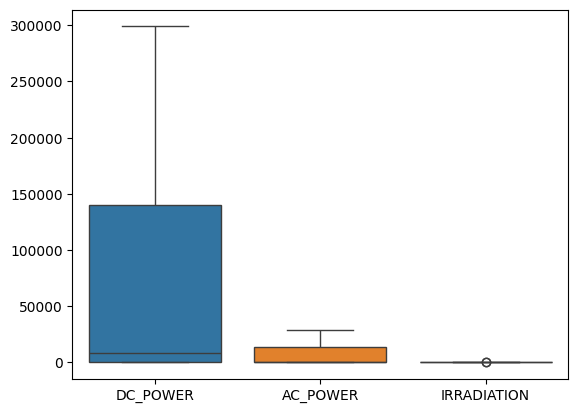

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=data[['DC_POWER', 'AC_POWER', 'IRRADIATION']])
plt.show() #This is done to check Outliers. But in this case (real world data) fluctuations and peaks are not outliers. They happen due to physical reasons.

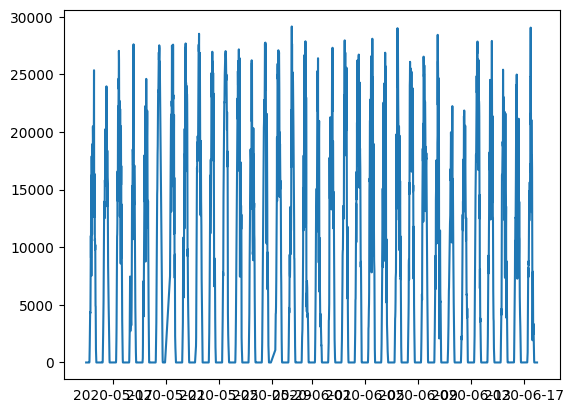

In [22]:
plt.plot(data['DATE_TIME'], data['AC_POWER'])

Adding time intelligence

In [23]:
data['hour_float'] = data['DATE_TIME'].dt.hour + data['DATE_TIME'].dt.minute / 60
data['day'] = data['DATE_TIME'].dt.day
data['month'] = data['DATE_TIME'].dt.month

In [24]:
data['hour_sin'] = np.sin(2 * np.pi * data['hour_float']/24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour_float']/24) # This encoding makes time cyclic, similar to a 24 hour clock

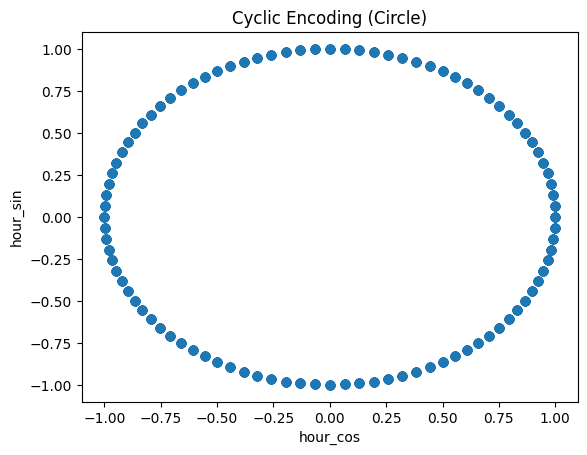

In [25]:
# Encoded Clock Representation
plt.figure()
plt.scatter(data['hour_cos'], data['hour_sin'])
plt.xlabel('hour_cos')
plt.ylabel('hour_sin')
plt.title('Cyclic Encoding (Circle)')
plt.show()

In [26]:
data = data.sort_values('DATE_TIME')

In [27]:
data = data.drop(columns = ['DATE_TIME'] )

In [28]:
data.head()

,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour_float,day,month,hour_sin,hour_cos
0,0.0,0.0,25.184316,22.857507,0.0,0.00,15,5,0.000000,1.000000
1,0.0,0.0,25.084589,22.761668,0.0,0.25,15,5,0.065403,0.997859
2,0.0,0.0,24.935753,22.592306,0.0,0.50,15,5,0.130526,0.991445
3,0.0,0.0,24.846130,22.360852,0.0,0.75,15,5,0.195090,0.980785
4,0.0,0.0,24.621525,22.165423,0.0,1.00,15,5,0.258819,0.965926


Train Test Split

In [29]:
X = data.drop(columns=['AC_POWER', 'DC_POWER'])
y = data['AC_POWER']

In [30]:
from sklearn.model_selection import train_test_split

train_size = int(len(data) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

Building Model

In [31]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [32]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(r2)

0.9960037576761951


In [33]:
data.corr()['AC_POWER'].sort_values(ascending=False)

,AC_POWER
AC_POWER,1.000000
DC_POWER,0.999997
IRRADIATION,0.995864
MODULE_TEMPERATURE,0.961011
AMBIENT_TEMPERATURE,0.725879
day,0.031099
hour_float,0.017352
hour_sin,-0.022060
month,-0.033504
hour_cos,-0.861409


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)

In [35]:
r2 = r2_score(y_test, y_pred2)
print(r2)

0.9919312716902655


Analysing high R2 score

In [36]:
X2 = data[['IRRADIATION']]

In [37]:
X2_train = X2[:train_size]
X2_test = X2[train_size:]

In [38]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X2_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [39]:
y_pred3 = model.predict(X2_test)
r2 = r2_score(y_test, y_pred3)
print(r2)

0.9934812795321091


In [40]:
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)
model2 = LinearRegression()
model2.fit(X2_train_scaled, y_train)

LinearRegression()

In [41]:
y_pred4 = model2.predict(X2_test_scaled)
r2 = r2_score(y_test, y_pred4)
print(r2)

0.9903694347799026


In [42]:
# Even by keeping X as just the column irradiation, we are getting high r2 scores for both random forest regression and linear regression. This means that the relationship between AC_POWER and IRRADIATION is highly linear.

Implementing Lag Features and Rolling windows

In [49]:
# Lag features
for lag in [1, 2, 3]:
    data[f'lag_{lag}'] = data['AC_POWER'].shift(lag)

# Rolling mean
for window in [3, 6, 12]:
    data[f'roll_mean_{window}'] = data['AC_POWER'].shift(1).rolling(window).mean()

# Drop NA
data = data.dropna()

# Features
X = data.drop(columns=['AC_POWER', 'DC_POWER','IRRADIATION'])
y = data['AC_POWER']

In [50]:
data.head()

,DC_POWER,AC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,hour_float,day,month,hour_sin,hour_cos,lag_1,lag_2,lag_3,roll_mean_3,roll_mean_6,roll_mean_12
24,942.148810,90.929167,24.088446,22.206757,0.005887,6.00,15,5,1.000000,6.123234e-17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25,6142.101190,593.338690,24.011635,22.353459,0.022282,6.25,15,5,0.997859,-6.540313e-02,90.929167,0.000000,0.000000,30.309722,15.154861,7.577431
26,15271.154762,1480.194643,23.976731,22.893282,0.049410,6.50,15,5,0.991445,-1.305262e-01,593.338690,90.929167,0.000000,228.089286,114.044643,57.022321
27,28626.589287,2790.448214,24.218990,24.442444,0.095394,6.75,15,5,0.980785,-1.950903e-01,1480.194643,593.338690,90.929167,721.487500,360.743750,180.371875
28,41345.914287,4052.662143,24.537398,27.185653,0.141940,7.00,15,5,0.965926,-2.588190e-01,2790.448214,1480.194643,593.338690,1621.327183,825.818452,412.909226


In [51]:
train_size = int(len(data) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

In [52]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [53]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(r2)

0.9548303784357399


In [ ]:
# Now the R2 score drops because the strongest feature irradiation was dropped. But still we are getting a good R2 score. This shows the importance and dependance of current value on past values and trend.